<b><h2>AI-Based Student Placement Prediction and Career Guidance System</h2></b>

In [4]:
import pandas as pd
import seaborn as sns

In [5]:
df=pd.read_csv("train.csv")

In [6]:
df

,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,1048,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,Not Placed
1,37820,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,Not Placed
2,49668,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,Not Placed
3,19467,22,Male,MCA,ME,7.78,2,4,6,6,90,4,2,0,Placed
4,23094,20,Female,B.Tech,ME,7.63,1,4,6,5,79,6,2,0,Placed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,9362,20,Male,MCA,Civil,7.84,2,5,9,7,68,6,3,1,Placed
44996,8940,19,Female,B.Sc,ME,8.28,1,4,6,5,74,5,2,0,Placed
44997,13097,20,Female,B.Sc,Civil,8.88,0,4,4,5,83,4,2,0,Not Placed
44998,12958,24,Female,MCA,ECE,5.90,1,3,6,6,60,2,2,1,Not Placed


In [7]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Degree', 'Branch', 'CGPA',
       'Internships', 'Projects', 'Coding_Skills', 'Communication_Skills',
       'Aptitude_Test_Score', 'Soft_Skills_Rating', 'Certifications',
       'Backlogs', 'Placement_Status'],
      dtype='object')

In [8]:
df.shape

(45000, 15)

In [9]:
df.isnull().sum()

Student_ID              0
Age                     0
Gender                  0
Degree                  0
Branch                  0
CGPA                    0
Internships             0
Projects                0
Coding_Skills           0
Communication_Skills    0
Aptitude_Test_Score     0
Soft_Skills_Rating      0
Certifications          0
Backlogs                0
Placement_Status        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.head()

,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,1048,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,Not Placed
1,37820,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,Not Placed
2,49668,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,Not Placed
3,19467,22,Male,MCA,ME,7.78,2,4,6,6,90,4,2,0,Placed
4,23094,20,Female,B.Tech,ME,7.63,1,4,6,5,79,6,2,0,Placed


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            45000 non-null  int64  
 1   Age                   45000 non-null  int64  
 2   Gender                45000 non-null  object 
 3   Degree                45000 non-null  object 
 4   Branch                45000 non-null  object 
 5   CGPA                  45000 non-null  float64
 6   Internships           45000 non-null  int64  
 7   Projects              45000 non-null  int64  
 8   Coding_Skills         45000 non-null  int64  
 9   Communication_Skills  45000 non-null  int64  
 10  Aptitude_Test_Score   45000 non-null  int64  
 11  Soft_Skills_Rating    45000 non-null  int64  
 12  Certifications        45000 non-null  int64  
 13  Backlogs              45000 non-null  int64  
 14  Placement_Status      45000 non-null  object 
dtypes: float64(1), int6

In [13]:
df.drop("Student_ID",axis=1,inplace=True)

In [14]:
df

,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,Not Placed
1,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,Not Placed
2,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,Not Placed
3,22,Male,MCA,ME,7.78,2,4,6,6,90,4,2,0,Placed
4,20,Female,B.Tech,ME,7.63,1,4,6,5,79,6,2,0,Placed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,20,Male,MCA,Civil,7.84,2,5,9,7,68,6,3,1,Placed
44996,19,Female,B.Sc,ME,8.28,1,4,6,5,74,5,2,0,Placed
44997,20,Female,B.Sc,Civil,8.88,0,4,4,5,83,4,2,0,Not Placed
44998,24,Female,MCA,ECE,5.90,1,3,6,6,60,2,2,1,Not Placed


#### Label Encoding For Categorical data

In [15]:
from sklearn.preprocessing import LabelEncoder

In [16]:
le=LabelEncoder()

In [17]:
df["Gender"]=le.fit_transform(df["Gender"])
df["Degree"]=le.fit_transform(df["Degree"])
df["Branch"]=le.fit_transform(df["Branch"])
df["Placement_Status"]=le.fit_transform(df["Placement_Status"])

In [18]:
df

,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,22,0,1,2,6.29,0,3,4,6,51,5,1,3,0
1,20,0,2,2,6.05,1,4,6,8,59,8,2,1,0
2,22,1,3,4,7.22,1,4,6,6,58,6,2,2,0
3,22,1,3,4,7.78,2,4,6,6,90,4,2,0,1
4,20,0,1,4,7.63,1,4,6,5,79,6,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,20,1,3,1,7.84,2,5,9,7,68,6,3,1,1
44996,19,0,0,4,8.28,1,4,6,5,74,5,2,0,1
44997,20,0,0,1,8.88,0,4,4,5,83,4,2,0,0
44998,24,0,3,2,5.90,1,3,6,6,60,2,2,1,0


In [19]:

import matplotlib.pyplot as plt

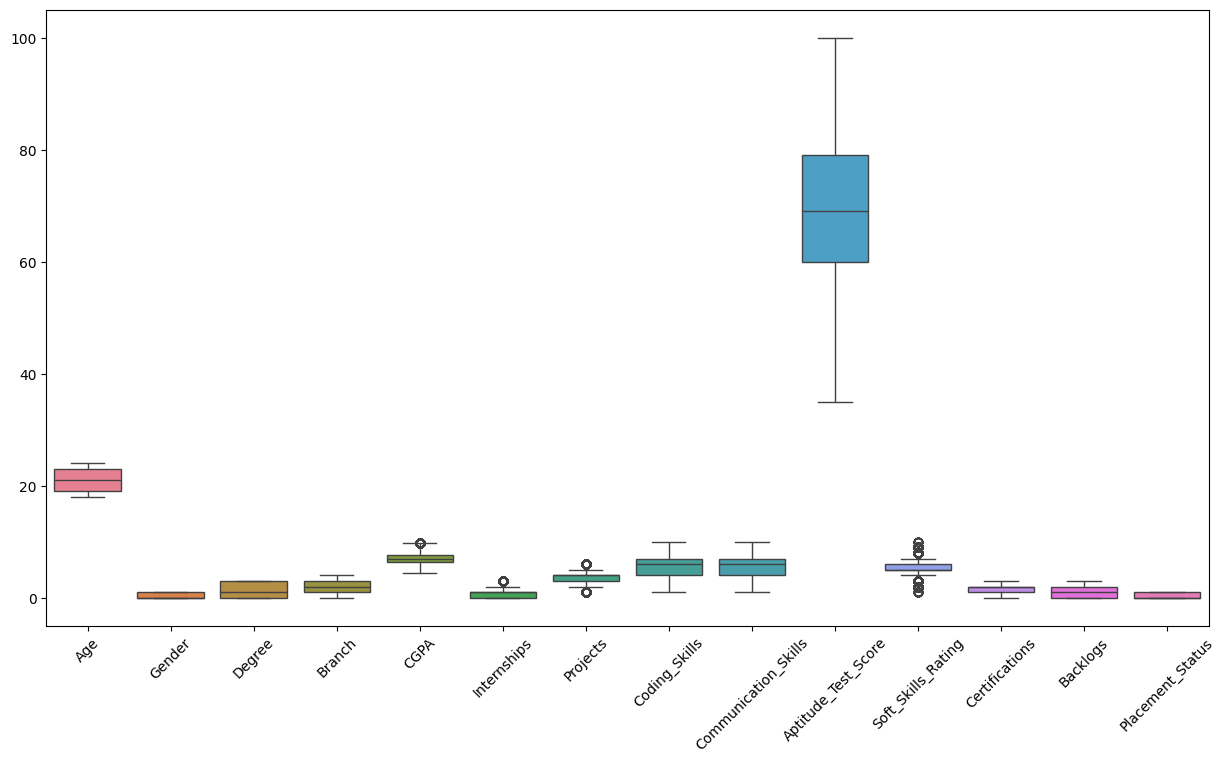

In [20]:
plt.figure(figsize=(15,8))# 15 width 8  height

sns.boxplot(data=df)

plt.xticks(rotation=45)
# x ticks it means x labels then rotation it means names cannot overlap names 

plt.show()

In [21]:
cols = [
    "CGPA",
    "Internships",
    "Projects",
    "Aptitude_Test_Score",
    "Soft_Skills_Rating",
    "Certifications"
]

In [22]:
for col in cols:

    Q1 = df[col].quantile(0.25)# quantile it means divide data into two prts
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower) &
        (df[col] <= upper)
    ]

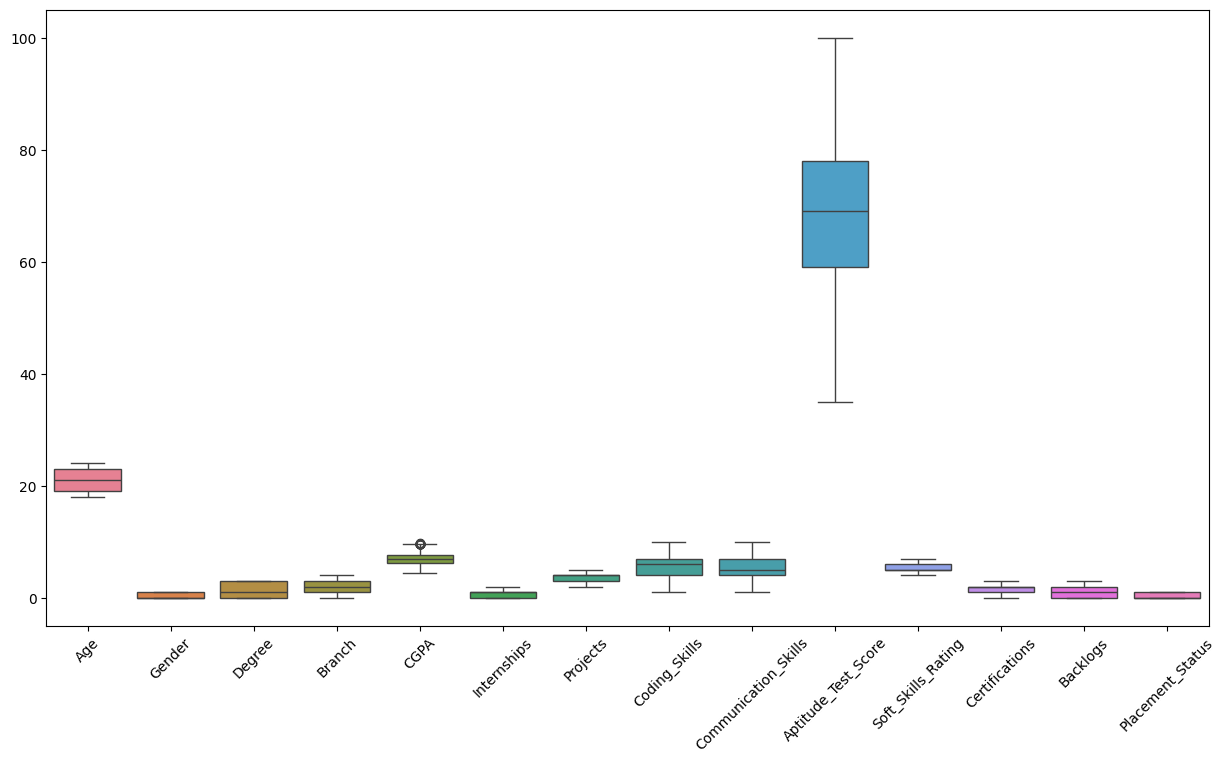

In [23]:
plt.figure(figsize=(15,8))# 15 width 8  height

sns.boxplot(data=df)

plt.xticks(rotation=45)
# x ticks it means x labels then rotation it means names cannot overlap names 

plt.show()

In [24]:
df.shape

(38192, 14)

### Placement Count

In [25]:
df.head()

,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,22,0,1,2,6.29,0,3,4,6,51,5,1,3,0
2,22,1,3,4,7.22,1,4,6,6,58,6,2,2,0
3,22,1,3,4,7.78,2,4,6,6,90,4,2,0,1
4,20,0,1,4,7.63,1,4,6,5,79,6,2,0,1
5,20,1,2,2,7.99,1,4,5,7,84,6,2,0,1


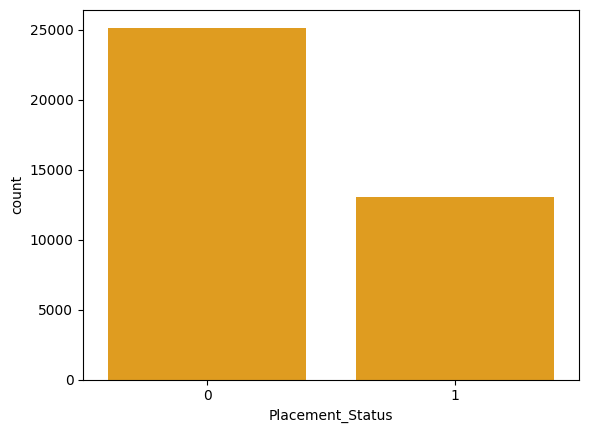

In [26]:
sns.countplot(x="Placement_Status",data=df,color="orange")
plt.show()

### CGPA Distribution

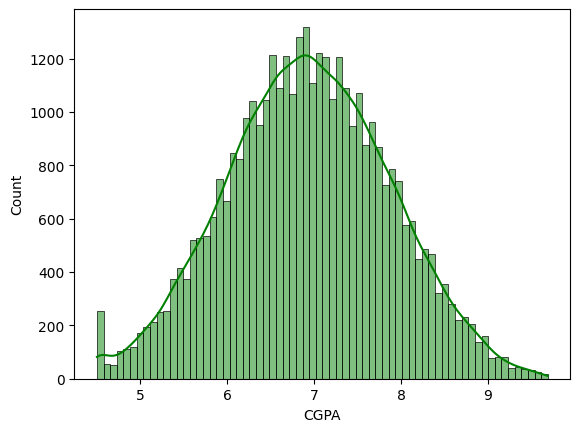

In [27]:
sns.histplot(df["CGPA"],kde=True,color="green")
plt.show()

### Balanced Data

In [28]:
df["Placement_Status"].value_counts()

Placement_Status
0    25143
1    13049
Name: count, dtype: int64

In [29]:
from imblearn.over_sampling import SMOTE

In [30]:
x=df.drop("Placement_Status",axis=1)
y=df["Placement_Status"]

In [31]:
sm=SMOTE()

In [32]:
x,y=sm.fit_resample(x,y)

In [33]:
x.shape

(50286, 13)

In [34]:
y.shape

(50286,)

### Train test
model performs on unseen data

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=32)

In [37]:
x_train.shape,y_train.shape

((40228, 13), (40228,))

In [38]:
x_test.shape,y_test.shape

((10058, 13), (10058,))

### Logistic Regression

In [39]:
from sklearn.linear_model import LogisticRegression

In [40]:
model= LogisticRegression()

In [41]:
model.fit(x_train,y_train)

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [42]:
ypred=model.predict(x_test)
ypred

array([1, 1, 0, ..., 0, 1, 1], shape=(10058,))

In [43]:
model.score(x_train,y_train),model.score(x_test,y_test)

(0.8607437605647807, 0.8585205806323325)

### SVM

In [44]:
from sklearn.svm import SVC

In [45]:
sv=SVC()

In [46]:
sv.fit(x_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [47]:
y_pred_sv=sv.predict(x_test)
y_pred_sv

array([1, 1, 0, ..., 0, 1, 1], shape=(10058,))

In [50]:
sv.score(x_train,y_train),sv.score(x_test,y_test)

(0.87697623545789, 0.8756213959037582)

### Knn

In [51]:
from sklearn.neighbors import KNeighborsClassifier


In [52]:

knn = KNeighborsClassifier()

In [53]:
knn.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [54]:

y_pred_knn = knn.predict(x_test)

In [55]:
knn.score(x_train,y_train),knn.score(x_test,y_test)

(0.9532166650094461, 0.9252336448598131)

### Naivy Bayes

In [56]:
from sklearn.naive_bayes import GaussianNB

In [57]:
nb = GaussianNB()

In [58]:
nb.fit(x_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [59]:
y_pred_nb = nb.predict(x_test)

In [60]:
nb.score(x_train,y_train),nb.score(x_test,y_test)

(0.8843840111365219, 0.8797971763770133)

In [63]:
from sklearn.metrics import confusion_matrix
#it can be used to evalute model performance 

In [64]:
cm=confusion_matrix(y_test,y_pred_knn)

In [65]:
cm

array([[4327,  712],
       [  40, 4979]])

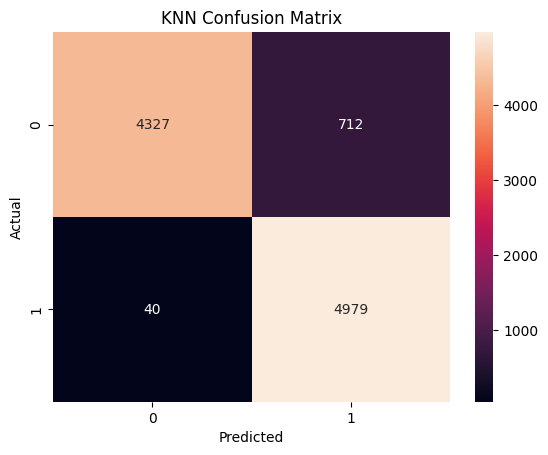

In [66]:
sns.heatmap(cm,annot=True,fmt="d")
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [67]:
from sklearn.metrics import classification_report

In [68]:
print("Classification Report:")
print(classification_report(y_test,y_pred_knn))

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      5039
           1       0.87      0.99      0.93      5019

    accuracy                           0.93     10058
   macro avg       0.93      0.93      0.92     10058
weighted avg       0.93      0.93      0.92     10058



### KNN is best model


KNN provided balanced and generalized performance with good prediction accuracy

In [69]:
import pickle

In [ ]:
with open ("knn.pkl","wb") as f:pickle.dump(knn,f)